# 🧠 RNN (Recurrent Neural Network) — Dizisel Veri & Bilgi Aktarımı

Bu notebook üç bölümden oluşur:

| Bölüm | İçerik |
|-------|--------|
| **1** | Teori: RNN nedir, formül nedir? |
| **2** | NumPy ile sıfırdan RNN hücresi |
| **3** | PyTorch `nn.RNN` ile gerçek sınıflandırıcı |

> **Çalıştırmak için:** `Kernel → Restart & Run All`


---
## 📖 Bölüm 1 — Teori: RNN Nasıl Çalışır?

### Klasik sinir ağından farkı nedir?

Normal (feedforward) bir ağda her girdi bağımsızdır — önceki adımı "hatırlamaz".  
RNN'de ise her adımda iki bilgi birleştirilir:

```
h_t = tanh( W_hh · h_{t-1}  +  W_xh · x_t  +  b_h )
y_t = W_hy · h_t  +  b_y
```

| Sembol | Boyut | Açıklama |
|--------|-------|----------|
| `x_t` | `(input_size,)` | Mevcut adımın girdisi |
| `h_{t-1}` | `(hidden_size,)` | **Bir önceki adımın gizli durumu** ← hafıza |
| `h_t` | `(hidden_size,)` | Yeni gizli durum (sonraki adıma aktarılır) |
| `W_hh` | `(H×H)` | Gizli-gizli ağırlık matrisi |
| `W_xh` | `(H×D)` | Girdi-gizli ağırlık matrisi |

> **Kritik nokta:** `W_hh`, `W_xh`, `W_hy` ağırlıkları **tüm adımlarda aynıdır**.  
> Bu paylaşım RNN'yi farklı uzunluktaki dizilere uygulanabilir kılar.

### Zaman içinde bilgi akışı

```
x₀  →  [RNN] → h₀  →  [RNN] → h₁  →  [RNN] → h₂  →  ...
              ↓               ↓               ↓
             y₀             y₁             y₂
```


---
## 🔧 Bölüm 2 — Kurulum & Kütüphaneler

Aşağıdaki hücre gerekli kütüphaneleri içe aktarır.  
`numpy` formülleri sıfırdan uygulamak, `torch` gerçek eğitim için kullanılacak.


In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Tekrarlanabilirlik için sabit tohum
np.random.seed(42)
torch.manual_seed(42)

print("✓ NumPy  :", np.__version__)
print("✓ PyTorch:", torch.__version__)


✓ NumPy  : 2.4.4
✓ PyTorch: 2.12.0+cu130


---
## 🔬 Bölüm 3 — Sıfırdan RNN (NumPy)

### `VanillaRNNCell` sınıfı

Bu sınıf PyTorch kullanmadan, tamamen NumPy ile bir RNN hücresi uygular.  
Amaç: formülün **tam olarak ne yaptığını** görmek.

**`__init__`:** Üç ağırlık matrisi ve iki bias başlatılır.  
**`forward_step`:** Tek bir `t` adımı için `h_t` ve `y_t` hesaplanır.  
**`forward_sequence`:** Döngüyle tüm dizi taranır; her adımın çıktısı saklanır.


In [2]:
class VanillaRNNCell:
    """
    Tek bir RNN hücresi — sıfırdan, sadece NumPy ile.

    Formül:
        h_t = tanh( W_hh @ h_{t-1}  +  W_xh @ x_t  +  b_h )
        y_t = W_hy @ h_t  +  b_y
    """
    def __init__(self, input_size: int, hidden_size: int, output_size: int):
        rng   = np.random.default_rng(42)
        scale = 0.01   # küçük başlangıç → patlayan gradient önlemi

        # ── Ağırlık matrisleri ──────────────────────────────────────
        # W_hh : gizli durumu bir sonraki adıma taşır  (hidden × hidden)
        self.W_hh = rng.standard_normal((hidden_size, hidden_size)) * scale

        # W_xh : mevcut girdiden gizli duruma katkı    (hidden × input)
        self.W_xh = rng.standard_normal((hidden_size, input_size))  * scale

        # W_hy : gizli durumdan çıktıya               (output × hidden)
        self.W_hy = rng.standard_normal((output_size, hidden_size)) * scale

        # ── Bias vektörleri ─────────────────────────────────────────
        self.b_h  = np.zeros(hidden_size)   # gizli katman biası
        self.b_y  = np.zeros(output_size)   # çıktı katmanı biası

        self.hidden_size = hidden_size

    # ────────────────────────────────────────────────────────────────
    def forward_step(self, x_t: np.ndarray, h_prev: np.ndarray):
        """
        Tek bir zaman adımı.

        Parametreler:
            x_t    : (input_size,)   ← mevcut adımın girdisi
            h_prev : (hidden_size,)  ← bir önceki adımın gizli durumu

        Döndürür:
            h_t : (hidden_size,)   ← YENİ gizli durum (sonraki adıma geçecek)
            y_t : (output_size,)   ← bu adımın çıktısı
        """
        # ① Gizli durumu güncelle — bilgi burada aktarılır
        #    W_hh @ h_prev  → geçmiş bilginin katkısı
        #    W_xh @ x_t    → mevcut girdinin katkısı
        #    tanh(...)      → -1..+1 aralığına sıkıştır
        h_t = np.tanh(self.W_hh @ h_prev + self.W_xh @ x_t + self.b_h)

        # ② Çıktıyı hesapla (genellikle yalnızca son adımda kullanılır)
        y_t = self.W_hy @ h_t + self.b_y

        return h_t, y_t

    # ────────────────────────────────────────────────────────────────
    def forward_sequence(self, X: np.ndarray):
        """
        Tam diziyi işle.

        Parametreler:
            X : (seq_len, input_size)

        Döndürür:
            H : (seq_len, hidden_size)  ← tüm adımların gizli durumları
            Y : (seq_len, output_size)  ← tüm adımların çıktıları
        """
        seq_len, _ = X.shape
        h = np.zeros(self.hidden_size)          # h_0 = sıfır vektörü

        H = np.zeros((seq_len, self.hidden_size))
        Y = np.zeros((seq_len, len(self.b_y)))

        # Her adımı sırayla işle; h öncekinden sonrakine aktarılır
        for t, x_t in enumerate(X):
            h, y  = self.forward_step(x_t, h)
            H[t]  = h
            Y[t]  = y

        return H, Y

print("VanillaRNNCell sınıfı tanımlandı ✓")


VanillaRNNCell sınıfı tanımlandı ✓


### Sıfırdan RNN — Test

5 adımlık bir dizi oluşturup hücreye veriyoruz.  
Her adımda `h_t`'nin nasıl değiştiğini L2 normuyla ölçeceğiz.


In [3]:
# ── Sahte dizi oluştur ───────────────────────────────────────
INPUT_SIZE  = 4
HIDDEN_SIZE = 8
OUTPUT_SIZE = 2
SEQ_LEN     = 5

X_dummy = np.random.randn(SEQ_LEN, INPUT_SIZE)

# ── Hücreyi çalıştır ─────────────────────────────────────────
cell = VanillaRNNCell(INPUT_SIZE, HIDDEN_SIZE, OUTPUT_SIZE)
H, Y = cell.forward_sequence(X_dummy)

print(f"Girdi  X : {X_dummy.shape}  (seq_len × input_size)")
print(f"Gizli  H : {H.shape}       (seq_len × hidden_size)")
print(f"Çıktı  Y : {Y.shape}        (seq_len × output_size)")
print()

# ── Adım adım norm değişimi ──────────────────────────────────
print(f"{'Adım':>5}  {'‖h_t‖ (L2)':>12}")
print("─" * 22)
for t, h_t in enumerate(H):
    print(f"{t:>5}  {np.linalg.norm(h_t):>12.5f}")

print(f"\nSon çıktı y_T : {Y[-1].round(5)}")


Girdi  X : (5, 4)  (seq_len × input_size)
Gizli  H : (5, 8)       (seq_len × hidden_size)
Çıktı  Y : (5, 2)        (seq_len × output_size)

 Adım    ‖h_t‖ (L2)
──────────────────────
    0       0.04349
    1       0.05222
    2       0.02118
    3       0.06301
    4       0.04833

Son çıktı y_T : [ 0.0003  -0.00031]


### Gizli Durum Isı Haritası

Aşağıdaki grafik her adımda `h_t`'nin hangi boyutlarının aktif olduğunu gösterir.  
Sarı = yüksek aktivasyon, Mor = düşük.  
Her satır bir zaman adımı, her sütun bir gizli boyutu temsil eder.


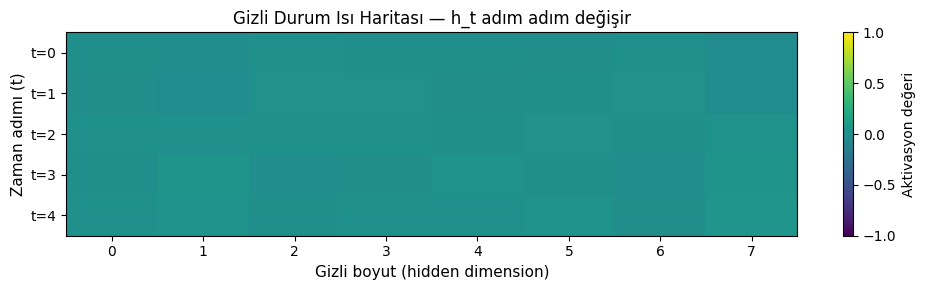

Isı haritası kaydedildi ✓


In [4]:
fig, ax = plt.subplots(figsize=(10, 3))
im = ax.imshow(H, aspect="auto", cmap="viridis", vmin=-1, vmax=1)
ax.set_xlabel("Gizli boyut (hidden dimension)", fontsize=11)
ax.set_ylabel("Zaman adımı (t)", fontsize=11)
ax.set_title("Gizli Durum Isı Haritası — h_t adım adım değişir", fontsize=12)
ax.set_yticks(range(SEQ_LEN))
ax.set_yticklabels([f"t={i}" for i in range(SEQ_LEN)])
plt.colorbar(im, ax=ax, label="Aktivasyon değeri")
plt.tight_layout()
plt.savefig("/tmp/rnn_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()
print("Isı haritası kaydedildi ✓")


---
## 🚀 Bölüm 4 — PyTorch `nn.RNN` ile Sınıflandırıcı

### `RNNClassifier` mimarisi

```
Girdi (batch, seq, feature)
    │
    ▼
nn.RNN  →  tüm adımların çıktısı  +  son gizli durum h_T
    │
    ▼ (yalnızca h_T alınır)
nn.Linear  →  sınıf logitleri
```

**Neden yalnızca son `h_T`?**  
Son gizli durum, dizinin tamamını özetler — tüm geçmiş adımların bilgisi orada birikmiştir.


In [5]:
class RNNClassifier(nn.Module):
    """
    Dizi → tek etiket sınıflandırması.

    Parametreler:
        input_size  : her adımın özellik sayısı
        hidden_size : RNN gizli durum boyutu
        num_classes : kaç sınıf var
        num_layers  : yığılmış RNN katman sayısı (varsayılan 1)
    """
    def __init__(self, input_size, hidden_size, num_classes, num_layers=1):
        super().__init__()

        # ── Ana RNN katmanı ──────────────────────────────────────────
        # batch_first=True  → (batch, seq, feature) formatını bekler
        # nonlinearity='tanh' → varsayılan aktivasyon
        self.rnn = nn.RNN(
            input_size   = input_size,
            hidden_size  = hidden_size,
            num_layers   = num_layers,
            batch_first  = True,
            nonlinearity = "tanh",
        )

        # ── Sınıflandırma başlığı ────────────────────────────────────
        # Sadece son adımın h_T'si kullanılır → (hidden_size → num_classes)
        self.fc = nn.Linear(hidden_size, num_classes)

    # ────────────────────────────────────────────────────────────────
    def forward(self, x):
        """
        x       : (batch, seq_len, input_size)

        Döndürür:
            logits : (batch, num_classes)
        """
        # nn.RNN iki şey döndürür:
        #   output : (batch, seq_len, hidden_size) — her adımın h_t'si
        #   h_n    : (num_layers, batch, hidden_size) — son adımın gizli durumu
        output, h_n = self.rnn(x)

        # Son katmanın son adımı → (batch, hidden_size)
        # Bu vektör tüm diziyi temsil eder
        last_hidden = h_n[-1]

        # Sınıflandırma
        logits = self.fc(last_hidden)   # (batch, num_classes)
        return logits

print("RNNClassifier tanımlandı ✓")
print()

# ── Model özeti ──────────────────────────────────────────────
model = RNNClassifier(input_size=10, hidden_size=32, num_classes=3)
print(model)

total_params = sum(p.numel() for p in model.parameters())
print(f"\nToplam parametre sayısı: {total_params:,}")


RNNClassifier tanımlandı ✓

RNNClassifier(
  (rnn): RNN(10, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=3, bias=True)
)

Toplam parametre sayısı: 1,507


### Veri Hazırlama & Eğitim Döngüsü

Gerçek bir veri setimiz olmadığı için sentetik (rastgele) dizi verisi üretiyoruz.  
Eğitim döngüsünün her adımı şunları yapar:

1. `model(X)` → ileri geçiş  
2. `CrossEntropyLoss` → kayıp hesapla  
3. `.backward()` → Backpropagation Through Time (BPTT)  
4. `optimizer.step()` → ağırlıkları güncelle


In [6]:
# ── Hiperparametreler ─────────────────────────────────────────
BATCH     = 64
SEQ_LEN   = 20
IN_SIZE   = 10
HID_SIZE  = 32
N_CLASSES = 3
EPOCHS    = 50
LR        = 1e-3

# ── Sentetik veri ─────────────────────────────────────────────
X_train = torch.randn(BATCH, SEQ_LEN, IN_SIZE)
y_train = torch.randint(0, N_CLASSES, (BATCH,))

# ── Model, kayıp fonksiyonu, optimizör ───────────────────────
model     = RNNClassifier(IN_SIZE, HID_SIZE, N_CLASSES)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

# ── Eğitim döngüsü ───────────────────────────────────────────
history = {"loss": [], "acc": []}

print(f"{'Epoch':>6}  {'Kayıp':>8}  {'Doğruluk':>10}")
print("─" * 32)

for epoch in range(1, EPOCHS + 1):
    model.train()
    optimizer.zero_grad()          # gradyanları sıfırla

    logits = model(X_train)        # ① İleri geçiş
    loss   = criterion(logits, y_train)  # ② Kayıp

    loss.backward()                # ③ BPTT — geri yayılım
    optimizer.step()               # ④ Ağırlık güncelleme

    # ── Metrikler ────────────────────────────────────────────
    with torch.no_grad():
        preds = logits.argmax(dim=1)
        acc   = (preds == y_train).float().mean().item() * 100

    history["loss"].append(loss.item())
    history["acc"].append(acc)

    if epoch % 10 == 0:
        print(f"{epoch:>6}  {loss.item():>8.4f}  {acc:>9.1f}%")

print("\nEğitim tamamlandı ✓")


 Epoch     Kayıp    Doğruluk
────────────────────────────────
    10    1.0355       48.4%
    20    0.9741       53.1%
    30    0.9070       59.4%
    40    0.8262       70.3%
    50    0.7365       78.1%

Eğitim tamamlandı ✓


### Eğitim Eğrisi

Kayıp ve doğruluk eğrilerini birlikte çiziyoruz.  
İyi bir eğitimde kayıp düşmeli, doğruluk yükselmeli.


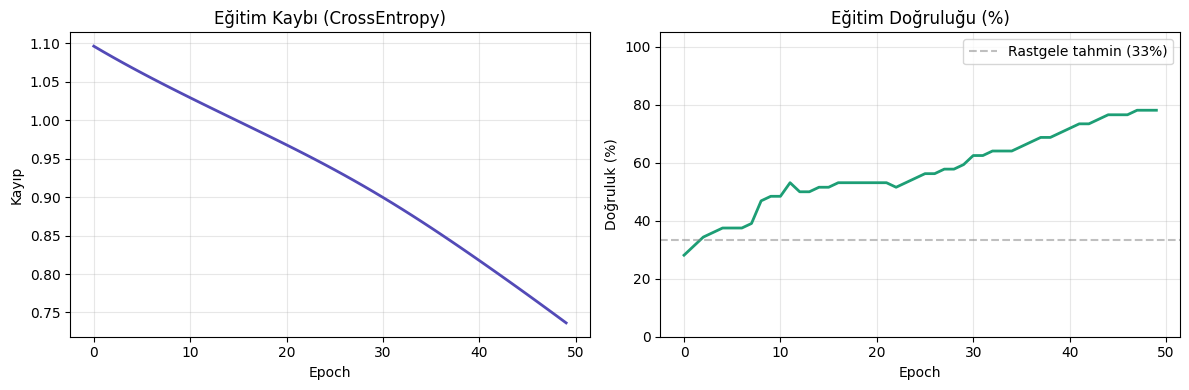

Eğitim eğrisi kaydedildi ✓


In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# ── Kayıp ────────────────────────────────────────────────────
ax1.plot(history["loss"], color="#534AB7", linewidth=2)
ax1.set_title("Eğitim Kaybı (CrossEntropy)", fontsize=12)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Kayıp")
ax1.grid(alpha=0.3)

# ── Doğruluk ─────────────────────────────────────────────────
ax2.plot(history["acc"], color="#1D9E75", linewidth=2)
ax2.set_title("Eğitim Doğruluğu (%)", fontsize=12)
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Doğruluk (%)")
ax2.set_ylim(0, 105)
ax2.axhline(33.3, color="gray", linestyle="--", alpha=0.5, label="Rastgele tahmin (33%)")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/tmp/rnn_training.png", dpi=120, bbox_inches="tight")
plt.show()
print("Eğitim eğrisi kaydedildi ✓")


---
## 🔍 Bölüm 5 — Adım Adım Gizli Durum İzleme

Eğitilmiş modelin **tek bir dizi** üzerinde adım adım nasıl ilerlediğini izleyelim.  
Her adımda `h_t`'yi yakalayarak gizli durumun nasıl evrildiğini göreceğiz.


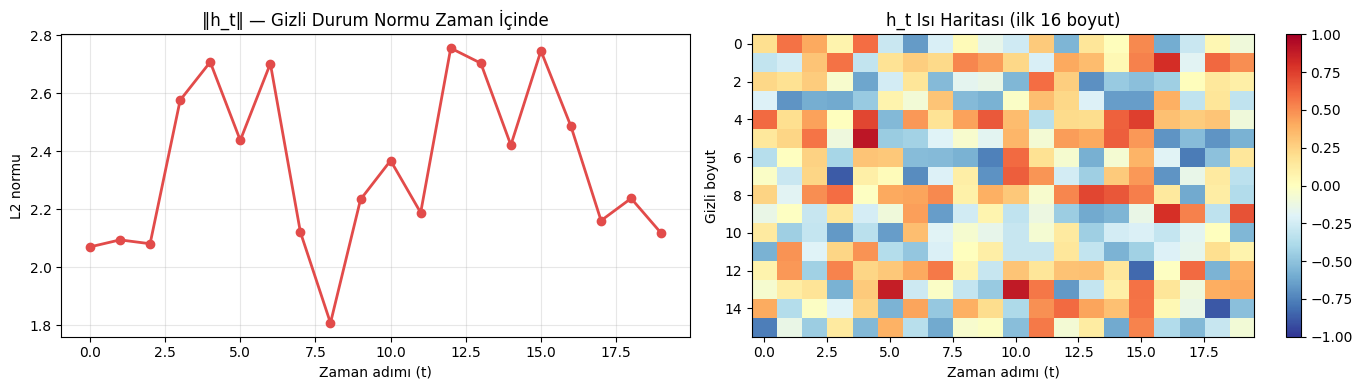

Gizli durum izleme grafiği kaydedildi ✓


In [8]:
model.eval()

# Tek bir test dizisi
test_seq = torch.randn(1, SEQ_LEN, IN_SIZE)   # (1, 20, 10)

hidden_states = []   # her adımın h_t'sini saklayacak

# Manuel adım adım işlem
h = None  # h_0 = None → PyTorch otomatik sıfırlar

with torch.no_grad():
    for t in range(SEQ_LEN):
        x_t    = test_seq[:, t:t+1, :]      # (1, 1, 10) — tek adım
        out, h = model.rnn(x_t, h)          # h güncelleniyor
        hidden_states.append(h[-1].squeeze().numpy())

# ── Norm grafiği ─────────────────────────────────────────────
norms = [np.linalg.norm(ht) for ht in hidden_states]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Sol: norm değişimi
ax1.plot(range(SEQ_LEN), norms, "o-", color="#E24B4A", linewidth=2, markersize=6)
ax1.set_title("‖h_t‖ — Gizli Durum Normu Zaman İçinde", fontsize=12)
ax1.set_xlabel("Zaman adımı (t)")
ax1.set_ylabel("L2 normu")
ax1.grid(alpha=0.3)

# Sağ: ısı haritası (ilk 16 boyut)
H_matrix = np.stack(hidden_states)[:, :16]
im = ax2.imshow(H_matrix.T, aspect="auto", cmap="RdYlBu_r", vmin=-1, vmax=1)
ax2.set_title("h_t Isı Haritası (ilk 16 boyut)", fontsize=12)
ax2.set_xlabel("Zaman adımı (t)")
ax2.set_ylabel("Gizli boyut")
plt.colorbar(im, ax=ax2)

plt.tight_layout()
plt.savefig("/tmp/rnn_hidden.png", dpi=120, bbox_inches="tight")
plt.show()
print("Gizli durum izleme grafiği kaydedildi ✓")


---
## 🎯 Bölüm 6 — Tahmin & Yorumlama

Modeli yeni bir dizi üzerinde çalıştırıp sınıf olasılıklarını görselleştirelim.


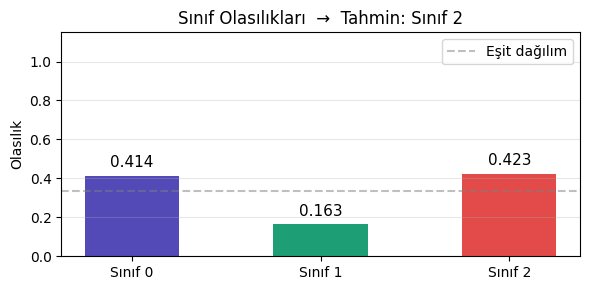

Tahmin edilen sınıf : 2
Olasılıklar         : [0.4137 0.1632 0.4231]


In [9]:
model.eval()

with torch.no_grad():
    yeni_dizi = torch.randn(1, SEQ_LEN, IN_SIZE)
    logit     = model(yeni_dizi)                           # (1, 3)
    olasilik  = torch.softmax(logit, dim=1).squeeze()      # (3,)
    tahmin    = olasilik.argmax().item()

siniflar = [f"Sınıf {i}" for i in range(N_CLASSES)]
renkler  = ["#534AB7", "#1D9E75", "#E24B4A"]

fig, ax = plt.subplots(figsize=(6, 3))
bars = ax.bar(siniflar, olasilik.numpy(), color=renkler, width=0.5)
ax.bar_label(bars, fmt="%.3f", padding=4, fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_title(f"Sınıf Olasılıkları  →  Tahmin: Sınıf {tahmin}", fontsize=12)
ax.set_ylabel("Olasılık")
ax.axhline(1/N_CLASSES, color="gray", linestyle="--", alpha=0.5, label="Eşit dağılım")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("/tmp/rnn_prediction.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"Tahmin edilen sınıf : {tahmin}")
print(f"Olasılıklar         : {olasilik.numpy().round(4)}")


---
## ⚠️ Bölüm 7 — RNN'nin Temel Zayıflığı: Kaybolan Gradient

### Problem

Backpropagation Through Time (BPTT) sırasında gradient, zaman boyunca geriye taşınır.  
Her adımda `tanh'ın türevi × W_hh` ile çarpılır.

Eğer `|W_hh| < 1` → gradient her adımda **küçülür** → uzak adımlar öğrenilmez.  
Eğer `|W_hh| > 1` → gradient her adımda **büyür** → eğitim kararsız hale gelir.

### Kaybolan Gradient — Görselleştirme


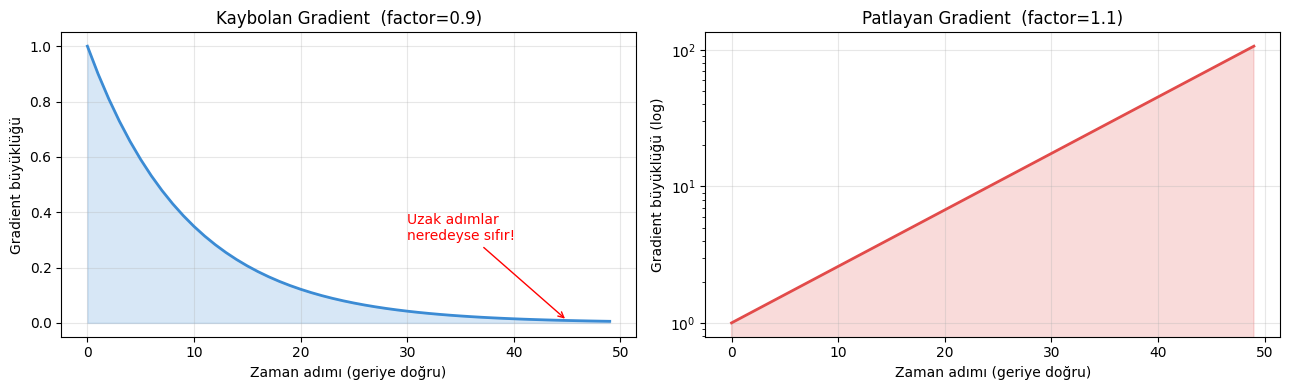

Kaybolan/patlayan gradient görselleştirildi ✓

Çözüm: LSTM ve GRU, bu problemi 'kapılar' (gates) ve
'hücre durumu' (cell state) ile çözer.


In [10]:
T = 50   # dizi uzunluğu

# Küçük gradient (kaybolan)
grad_vanish = [0.9**t for t in range(T)]

# Büyük gradient (patlayan)
grad_explode = [min(1.1**t, 1e6) for t in range(T)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(grad_vanish, color="#3B8BD4", linewidth=2)
ax1.set_title("Kaybolan Gradient  (factor=0.9)", fontsize=12)
ax1.set_xlabel("Zaman adımı (geriye doğru)")
ax1.set_ylabel("Gradient büyüklüğü")
ax1.fill_between(range(T), grad_vanish, alpha=0.2, color="#3B8BD4")
ax1.grid(alpha=0.3)
ax1.annotate("Uzak adımlar\nneredeyse sıfır!", xy=(45, grad_vanish[45]),
             xytext=(30, 0.3), arrowprops=dict(arrowstyle="->", color="red"),
             fontsize=10, color="red")

ax2.plot(grad_explode, color="#E24B4A", linewidth=2)
ax2.set_title("Patlayan Gradient  (factor=1.1)", fontsize=12)
ax2.set_xlabel("Zaman adımı (geriye doğru)")
ax2.set_ylabel("Gradient büyüklüğü (log)")
ax2.set_yscale("log")
ax2.fill_between(range(T), grad_explode, alpha=0.2, color="#E24B4A")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/tmp/rnn_gradient.png", dpi=120, bbox_inches="tight")
plt.show()

print("Kaybolan/patlayan gradient görselleştirildi ✓")
print()
print("Çözüm: LSTM ve GRU, bu problemi 'kapılar' (gates) ve")
print("'hücre durumu' (cell state) ile çözer.")


---
## 📋 Özet

| Konu | Açıklama |
|------|----------|
| **Temel formül** | `h_t = tanh(W_hh·h_{t-1} + W_xh·x_t + b_h)` |
| **Paylaşılan ağırlıklar** | Tüm adımlarda `W_hh, W_xh, W_hy` aynıdır |
| **Gizli durum** | `h_t` önceki tüm adımların özetidir |
| **Eğitim** | BPTT (Backpropagation Through Time) |
| **Zayıflık** | Uzun dizilerde kaybolan/patlayan gradient |
| **Çözüm** | LSTM (kapılar + hücre durumu) |

### Sonraki Adım → LSTM

```
LSTM'de 3 kapı vardır:
  • Unutma kapısı (forget gate)  : neyi unut?
  • Giriş kapısı  (input gate)   : neyi ekle?
  • Çıkış kapısı  (output gate)  : neyi çıkar?
```
